<a href="https://colab.research.google.com/github/sadiksha1920/DSA/blob/master/day_3_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating dataset with pandas and numpy

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_rows = 500
data = {
    "area_sqft": np.random.randint(500,4000,n_rows),

}
df = pd.DataFrame(data)

In [ ]:
#Price formula (realistic relationship + noise)
df["price"]=(
    df["area_sqft"]* 120
).astype(int)
df.head(10)

,area_sqft,price
0,3674,440880
1,1360,163200
2,1794,215280
3,1630,195600
4,1595,191400
5,3592,431040
6,2138,256560
7,2669,320280
8,966,115920
9,1738,208560


In [ ]:
df

,area_sqft,price
0,3674,440880
1,1360,163200
2,1794,215280
3,1630,195600
4,1595,191400
...,...,...
495,2697,323640
496,2861,343320
497,3117,374040
498,3913,469560


In [ ]:
df.isna().sum()

,0
area_sqft,0
price,0


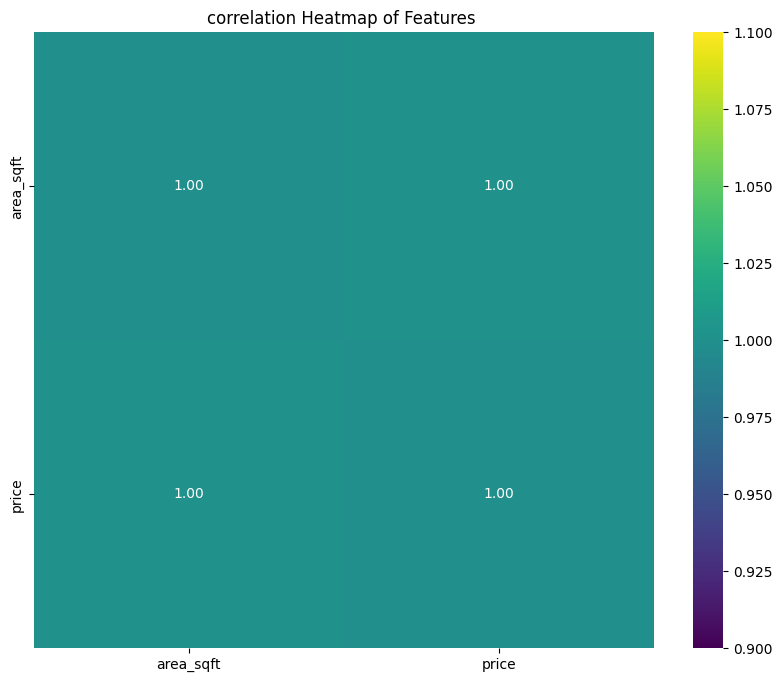

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='viridis',fmt=".2f")
plt.title("correlation Heatmap of Features ")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

Simple Regression

In [ ]:
X_simple = df[["area_sqft"]]
y = df["price"]

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(
    X_simple,y,test_size=0.2, random_state=42)


In [ ]:
simple_model = LinearRegression()
simple_model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred_simple = simple_model.predict(X_test)

In [ ]:
print(f"Price = {simple_model.coef_[0]:.2f}* area_sqft + {simple_model.intercept_:.2f}")

Price = 120.00* area_sqft + -0.00


In [ ]:
# Example: predict price for 1500 sqft house
new_area = np.array([[1500]])
predicted_price = simple_model.predict(new_area)
print(f"Predicted Price for 1500 sqft: {predicted_price[0]:.2f}")

Predicted Price for 1500 sqft: 180000.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print("Simple Linear Regression")
print("MAE:",mean_absolute_error(y_test,y_pred_simple))
print("MSE:" , mean_squared_error(y_test,y_pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_simple)))
print("R^2 Score:", r2_score(y_test,y_pred_simple))


Simple Linear Regression
MAE: 4.627509042620659e-11
MSE: 3.316133988500586e-21
RMSE: 5.758588358704402e-11
R^2 Score: 1.0


=> 121.53 is the Coefficient (m) → price increases by 121.53 per extra sqft

=> area_sqft is the Input variable

=> 18432.67 is the Intercept (b) → base price when area = 0


Multiple Linear Regression

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_rows = 500
data = {
    "area_sqft": np.random.randint(500, 4000, n_rows),
    "bedrooms": np.random.randint(1, 6, n_rows),
    "bathrooms": np.random.randint(1, 4, n_rows),
    "floors": np.random.randint(1, 4, n_rows),
    "year_built": np.random.randint(1970, 2024, n_rows),
    "distance_city_km": np.round(np.random.uniform(1, 40, n_rows), 2),
    "has_garage": np.random.randint(0, 2, n_rows),
    "has_garden": np.random.randint(0, 2, n_rows),
}
df = pd.DataFrame(data)

In [ ]:
# Price formula (realistic relationship + noise)
df["price"] = (
    df["area_sqft"] * 120
    + df["bedrooms"] * 15000
    + df["bathrooms"] * 10000
    + df["floors"] * 8000
    + df["year_built"] * 300
    - df["distance_city_km"] * 2500
    + df["has_garage"] * 12000
    + df["has_garden"] * 10000
    + np.random.normal(0, 20000, n_rows)
).astype(int)
df.head()

,area_sqft,bedrooms,bathrooms,floors,year_built,distance_city_km,has_garage,has_garden,price
0,3674,4,3,2,2001,26.81,1,0,1106728
1,1360,2,2,1,2020,22.75,1,0,772561
2,1794,3,2,3,2013,29.50,1,0,866978
3,1630,4,3,1,1987,19.14,0,0,828575
4,1595,5,3,3,1975,3.35,1,0,913333


In [ ]:
df.columns

Index(['area_sqft', 'bedrooms', 'bathrooms', 'floors', 'year_built',
       'distance_city_km', 'has_garage', 'has_garden', 'price'],
      dtype='object')

In [ ]:
X_multi = df[
    [
        "area_sqft", "bedrooms", "bathrooms", "floors", 'year_built',
        "distance_city_km", "has_garage", "has_garden",
    ]]
y = df["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42)

In [ ]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_multi = multi_model.predict(X_test)

In [ ]:
new_data = pd .DataFrame({
    "area_sqft": [1500],
    "bedrooms": [3],
    "bathrooms": [2],
    "floors": [2],
    "year_built": [1987],
    "distance_city_km":[5],
    "has_garage":[1],
    "has_garden":[1]
})
prediction = multi_model.predict(new_data)
print("Predicted Price:", prediction[0])

Predicted Price: 865999.5471704737


In [ ]:
coeff_df = pd.DataFrame({
    "Feature": X_multi.columns,
    "Coefficient": multi_model.coef_
})
coeff_df

,Feature,Coefficient
0,area_sqft,120.350257
1,bedrooms,13624.206673
2,bathrooms,8738.851621
3,floors,9372.015301
4,year_built,266.369136
5,distance_city_km,-2480.613842
6,has_garage,14151.484775
7,has_garden,10036.726601


In [ ]:
print("\nMultiple Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_multi))
print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi)))
print("R² Score:", r2_score(y_test, y_pred_multi))


Multiple Linear Regression
MAE: 16844.946364449104
MSE: 409500604.19620043
RMSE: 20236.12127350991
R² Score: 0.968565754651432


MAE: 35366.771007361676

MSE: 1840105093.1558673

RMSE: 42896.44615997772

R² Score: 0.8597069253778217

Positive coefficient increases

Negative coefficient decreases price

Multiple regression captures more real-world factors, so it usually gives a much better R² score.

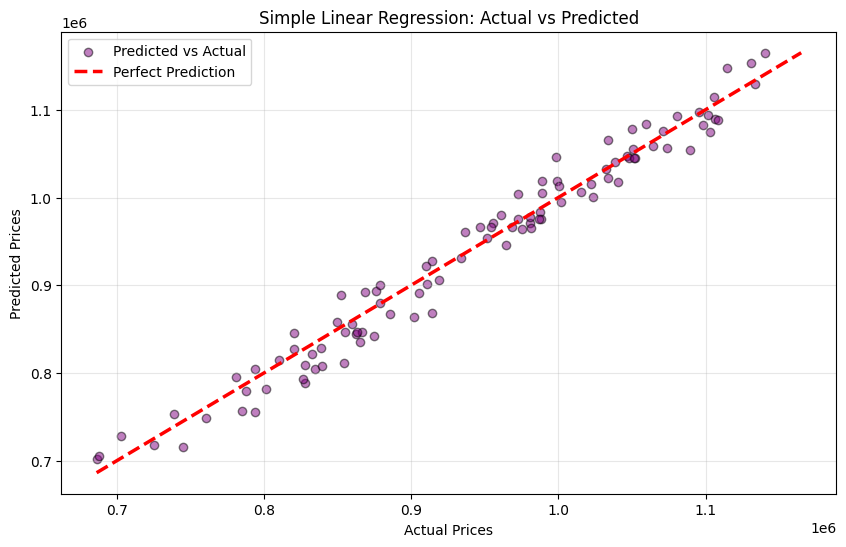

In [ ]:
plt.figure(figsize=(10, 6))

# Actual vs Predicted scatter
plt.scatter(
    y_test,
    y_pred_multi,
    color='purple',
    alpha=0.5,
    edgecolor='black',
    label='Predicted vs Actual'
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_multi.min())
max_val = max(y_test.max(), y_pred_multi.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=2.5,
    label='Perfect Prediction'
)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Simple Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

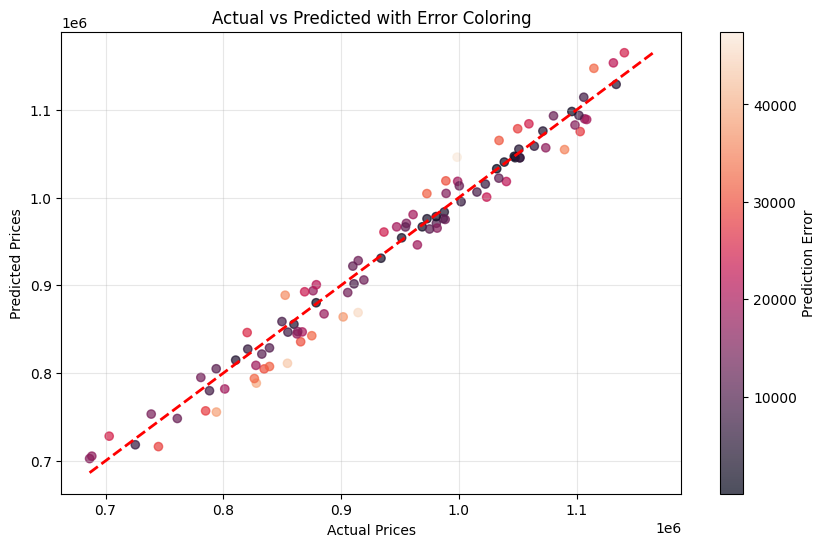

In [ ]:
import matplotlib.pyplot as plt

errors = abs(y_test - y_pred_multi)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    y_test, y_pred_multi,
    c=errors,
    cmap='rocket',
    alpha=0.7)
plt.colorbar(scatter, label='Prediction Error')
min_val = min(y_test.min(), y_pred_multi.min())
max_val = max(y_test.max(), y_pred_multi.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--', linewidth=2)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted with Error Coloring')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
x = df['area_sqfit'].values
y = df["price"].values

KeyError: 'area_sqfit'

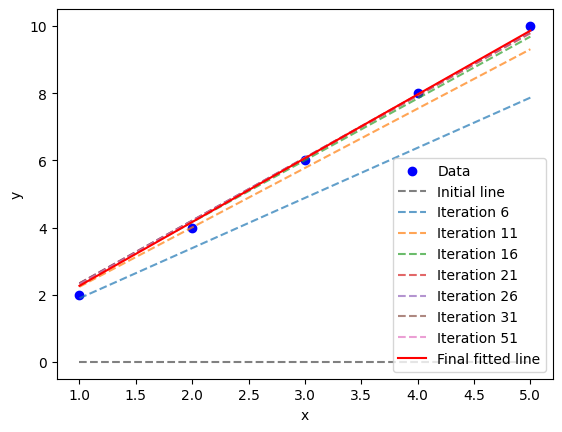

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simple dataset
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Initialize weights
m, b = 0, 0
lr = 0.01
iters = 100

# Store weights for plotting
m_history, b_history = [], []

# Gradient descent loop
for i in range(iters):  #number of time we update our weight
    y_pred = m*x + b  #predicted values using the current slope m and intercept b.
    dm = (-2/len(x)) * np.sum(x*(y - y_pred)) #gradient of the loss (MSE) with respect to the slope m.
    db = (-2/len(x)) * np.sum(y - y_pred) #calculates the gradient of the loss with respect to intercept b.
    m -= lr * dm  #updates the slope by moving it in the opposite direction of the gradient
    b -= lr * db  #updates the intercept in the same way as the slope.
    m_history.append(m) #Store the updated weights
    b_history.append(b)
# Plot the unfit, intermediate, and final lines
plt.scatter(x, y, color='blue', label='Data')
# Unfit line (initial)
plt.plot(x, 0*x + 0, '--', color='gray', label='Initial line')
# Few intermediate lines
for i in [5, 10, 15, 20, 25, 30, 50]:
    plt.plot(x, m_history[i]*x + b_history[i], '--', alpha=0.7, label=f'Iteration {i+1}')
# Final line
plt.plot(x, m*x + b, color='red', label='Final fitted line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()